In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from scipy.integrate import simpson

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/UGC-5823_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

image_cut = image[48:168, 0:1890]
image_error_cut = image_error[48:168, 0:1890]

wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.0188
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/UGC-5823_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [5]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
    
def sersic_1d_convolved(x, params):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, params)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

def model_convolved(x, params1, params2, params3, params4, params5, params6, params7):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) +
        sersic_1d(x_hr, params4) +
        sersic_1d(x_hr, params5) +
        sersic_1d(x_hr, params6) +
        sersic_1d(x_hr, params7)
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out
    
def integrate(x, y):
    integrale = np.zeros(y.shape[0]-1)
    integrale[0] = (y[1]+ y[0])*(x[1]-x[0])* 0.5
    for i in range(1, len(y)-1):
        integrale[i] = integrale[i-1] + (y[i+1]+ y[i])*(x[i+1]-x[i])* 0.5
    return integrale, 0.5*(x[1:]+x[:-1])
     
def separation(x, params1, params2):
    
    sersic_1 = sersic_1d_convolved(x, params1)
    sersic_2 = sersic_1d_convolved(x, params2)

    #CDFs of the two sersic
    L_1, x1 = integrate(x, sersic_1)
    L_2, x2 = integrate(x, sersic_2)

    #Find the point where is the maximum distances bt cdfs 
    index_max_diff = np.argmax(np.abs(L_2 - L_1))
    print(x2[index_max_diff])  
    x_separation = x2[index_max_diff]
    return x_separation
    
def sep_all(x, params1, params2, params3, params4, params5, params6, params7):
      # Coppie con params1
    x_12 = separation(x, params1, params2)
    x_13 = separation(x, params1, params3)
    x_14 = separation(x, params1, params4)
    x_15 = separation(x, params1, params5)
    x_16 = separation(x, params1, params6)
    x_17 = separation(x, params1, params7)
    
    # Coppie con params2 (escluse quelle già calcolate)
    x_23 = separation(x, params2, params3)
    x_24 = separation(x, params2, params4)
    x_25 = separation(x, params2, params5)
    x_26 = separation(x, params2, params6)
    x_27 = separation(x, params2, params7)
    
    # Coppie con params3 (escluse quelle già calcolate)
    x_34 = separation(x, params3, params4)
    x_35 = separation(x, params3, params5)
    x_36 = separation(x, params3, params6)
    x_37 = separation(x, params3, params7)
    
    # Coppie con params4 (escluse quelle già calcolate)
    x_45 = separation(x, params4, params5)
    x_46 = separation(x, params4, params6)
    x_47 = separation(x, params4, params7)
    
    # Coppie con params5 (escluse quelle già calcolate)
    x_56 = separation(x, params5, params6)
    x_57 = separation(x, params5, params7)
    
    # Coppie con params6 (escluse quelle già calcolate)
    x_67 = separation(x, params6, params7)
    sep = [x_12, x_13, x_14, x_15, x_16, x_17, x_23, x_24, x_25, x_26, x_27, x_34, x_35, x_36, x_37, x_45, x_46, x_47, x_56, x_57, x_67]
    return sep

In [6]:
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/PSF/Real_seeing_UGC5823_1.txt")
sigma = seeing[-1] / 2.35
x_axes = np.arange(0, 120, 1)

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))
fit = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Fit/Halpha_fit.csv", index_col=0)

32.5
44.5
118.5
44.5
81.5
118.5
51.5
118.5
59.5
82.5
115.5
118.5
58.5
80.5
118.5
71.5
84.5
87.5
85.5
109.5
118.5


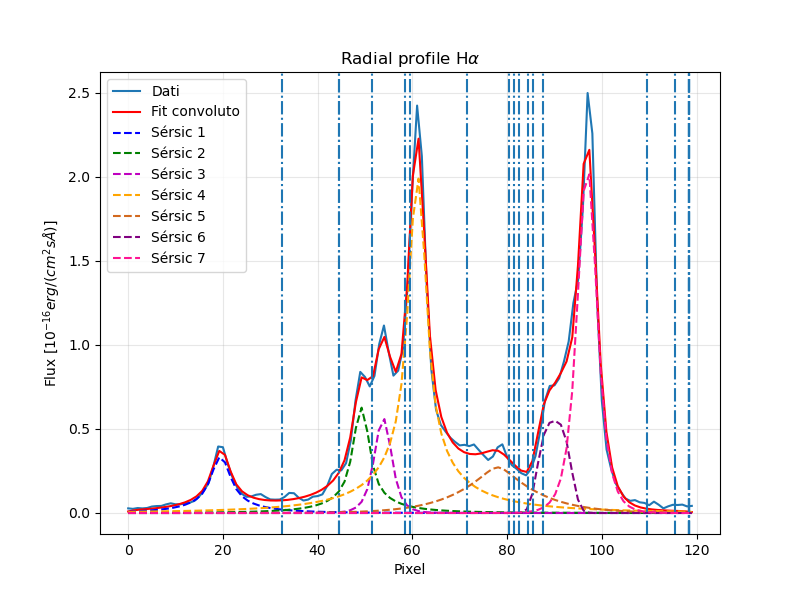

In [11]:
separations = sep_all(x_axes, fit['Component 1'], fit['Component 2'], fit['Component 3'],
                        fit['Component 4'], fit['Component 5'], fit['Component 6'], fit['Component 7'])

xgrid = np.linspace(min(x_axes), max(x_axes), 100)

y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], fit['Component 3'],
                        fit['Component 4'], fit['Component 5'], fit['Component 6'], fit['Component 7'])

plt.figure(figsize=(8, 6))
plt.plot(x_axes, radial_profile_HA, label='Dati')
plt.plot(xgrid, y_fit, 'r-', label='Fit convoluto')

# Componenti singoli
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 1']), 'b--', label='Sérsic 1')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 2']), 'g--', label='Sérsic 2')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 3']), 'm--', label='Sérsic 3')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 4']), color='orange', linestyle='--', label='Sérsic 4')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 5']), color='chocolate', linestyle='--', label='Sérsic 5')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 6']), color='purple', linestyle='--', label='Sérsic 6')
plt.plot(xgrid, sersic_1d_convolved(xgrid, fit['Component 7']), color='deeppink', linestyle='--', label='Sérsic 7')

plt.xlabel("Pixel")
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
plt.title(r"Radial profile H$\alpha$")

plt.grid(alpha = 0.3)
#plt.ylim(0, 12.5)
for i in separations:
    plt.axvline(i, linestyle = '-.',)
plt.legend()
plt.savefig('CDFs_sep')